In [1]:
#--- Install Necessary Databases ---

!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 3.8323000000000174 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                    

In [3]:
#--- Install Necessary Databases ---

import pandas as pd

In [4]:
#--- Install Necessary Databases ---

df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

In [6]:
#--- Check head of dataframe to see what fields are included ---

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
#--- Check for unique values in total encounters ---

df['encounter_id'].is_unique

True

In [8]:
#--- Set new index to unique column and check head of dataframe to confirm switch ---

df = df.set_index('encounter_id')
df.head()

,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
encounter_id,,,,,,,,,,,,,,,,,,,,,
2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,...,No,No,No,No,No,No,No,No,No,NO
149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,>30
64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,NO
500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,NO
16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [48]:
#--- Checking values for use in analysis - using print function to check columns and values to see what might need to be cleaned up ---

print(df.columns)

print(df['A1Cresult'].sort_values().unique())

Index(['patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')
<StringArray>
['>7', '>8', 'Norm', nan]
Length: 4, dtype: str


In [9]:
#--- Update dataframe to drop columns not needed for analysis ---

drop_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures',  'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone']

df.drop(drop_cols, inplace = True, axis=1)

df.head()

,patient_nbr,race,gender,age,weight,time_in_hospital,num_medications,number_diagnoses,A1Cresult,change,diabetesMed,readmitted
encounter_id,,,,,,,,,,,,
2278392,8222157,Caucasian,Female,[0-10),?,1,1,1,NaN,No,No,NO
149190,55629189,Caucasian,Female,[10-20),?,3,18,9,NaN,Ch,Yes,>30
64410,86047875,AfricanAmerican,Female,[20-30),?,2,13,6,NaN,No,Yes,NO
500364,82442376,Caucasian,Male,[30-40),?,2,16,7,NaN,Ch,Yes,NO
16680,42519267,Caucasian,Male,[40-50),?,1,8,5,NaN,Ch,Yes,NO


In [10]:
#--- Check for null values in dataframe and replace if necessary ---

df.isnull().sum()

patient_nbr             0
race                    0
gender                  0
age                     0
weight                  0
time_in_hospital        0
num_medications         0
number_diagnoses        0
A1Cresult           84748
change                  0
diabetesMed             0
readmitted              0
dtype: int64

In [11]:
#--- Confirm shape of current dataframe ---

df.shape

(101766, 12)

In [12]:
#--- drop missing values and check shape to confirm ---

df.dropna()

df.shape

(101766, 12)

In [13]:
#--- Since no rows were dropped and there are still null values, replace NaNs with a value to allow for ease of filtering and dropping data ---

df.fillna({'A1Cresult': 'N/A'}, inplace=True)

#--- check if null values replaced ---

df.isnull().sum()

patient_nbr         0
race                0
gender              0
age                 0
weight              0
time_in_hospital    0
num_medications     0
number_diagnoses    0
A1Cresult           0
change              0
diabetesMed         0
readmitted          0
dtype: int64

In [17]:
#--- Use new value to filter out rows with null values ---

df_clean = df[df['A1Cresult'] != 'N/A']

#--- Check shape of new dataframe; if the total number of rows decreased, the filter was able to remove the null values ---

df_clean.shape

(17018, 12)

In [18]:
#--- Repeat clean for weight and race columns ---

df_clean = df_clean[df_clean['weight'] != '?']
df_clean = df_clean[df_clean['race'] != '?']

#--- Check cleaned dataframe for nulls that were removed ---

print(df_clean['A1Cresult'].sort_values().unique())
print(df_clean['weight'].sort_values().unique())
print(df_clean['race'].sort_values().unique())

<StringArray>
['>7', '>8', 'Norm']
Length: 3, dtype: str
<StringArray>
[   '[0-25)', '[100-125)', '[125-150)', '[150-175)', '[175-200)',   '[25-50)',
   '[50-75)',  '[75-100)']
Length: 8, dtype: str
<StringArray>
['AfricanAmerican', 'Asian', 'Caucasian', 'Other']
Length: 4, dtype: str


In [56]:
#--- Check head of new dataframe for cleaned up source for analysis ---

df_clean.head()

,patient_nbr,race,gender,age,weight,time_in_hospital,num_medications,number_diagnoses,A1Cresult,change,diabetesMed,readmitted
encounter_id,,,,,,,,,,,,
8576406,80041266,Caucasian,Female,[80-90),[50-75),9,17,7,>8,Ch,Yes,>30
8866632,103586670,Caucasian,Male,[70-80),[100-125),6,20,7,>8,No,Yes,>30
9198750,81133947,Caucasian,Male,[50-60),[75-100),2,3,4,>7,No,No,<30
16623912,107804349,Caucasian,Male,[70-80),[50-75),7,16,7,>8,Ch,Yes,>30
17563668,74612331,Caucasian,Female,[70-80),[75-100),10,17,7,>7,No,No,>30


In [19]:
#--- Research question: Do patients with higher A1C's get discharged with changes in their medication regimen? ---

# Need to group by A1C result and compare how many had changes to their medication regimen upon discharge

# Check to see how many medications members have on average (and confirm the cohort has at least one medication) 

df_clean.describe()

,patient_nbr,time_in_hospital,num_medications,number_diagnoses
count,3.310000e+02,331.000000,331.000000,331.000000
mean,7.410177e+07,5.018127,16.574018,7.936556
std,3.326280e+07,3.021083,8.064313,1.701753
min,2.809890e+05,1.000000,1.000000,1.000000
25%,5.609560e+07,3.000000,11.000000,7.000000
50%,8.071673e+07,4.000000,16.000000,9.000000
75%,9.936852e+07,7.000000,21.000000,9.000000
max,1.842748e+08,14.000000,48.000000,9.000000


<Axes: title={'center': 'Number of Patients with Changed Medications at Discharge by A1C'}, xlabel='A1C Group', ylabel='Number of Patients'>

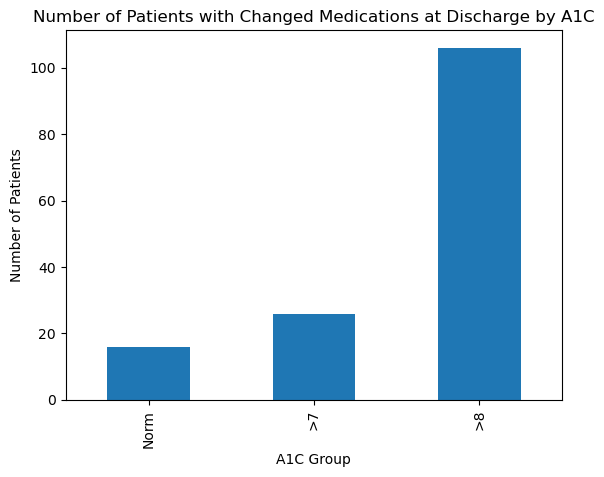

In [20]:
#Confirmed: cohort has minimum 1 medcication to be assessed in analysis and an average of 16 medications per patient

#--- Filter for data of just patients with changed medications ---

df_changed = df_clean[df_clean['change'] == 'Ch']

df_changed.groupby(['A1Cresult'])['change'].count().sort_values().plot(kind='bar', title='Number of Patients with Changed Medications at Discharge by A1C', xlabel='A1C Group', ylabel='Number of Patients')

In [64]:
# CONCLUSION: Patients with higher A1Cs (<8) had more changes to their medications upon discharged compared to those with normal A1Cs and significantly more than those with >7 A1C.